# Report labeler — Qwen2.5-1.5B

Reads each study's radiology report and extracts the 12 abnormality labels as
JSON, leaving `?` wherever the report does not say. Output feeds `train.csv`,
which is otherwise mostly unlabelled.

Running on Kaggle 2×T4:

| choice | why |
| --- | --- |
| Qwen2.5-1.5B-Instruct, not 7B | ~3 GB in fp16, fits trivially on one T4 |
| fp16, no quantization | nf4 is *slower* than fp16 on Turing, and T4 has no bf16 |
| batched generation | where the real 15–25× speedup comes from |
| chat template applied | Instruct models degrade badly without it |
| one full replica per GPU | rather than `device_map="auto"` layer sharding |

> **Note.** Labels derived from reports are pseudo-labels for the *image* branch
> only. Training a text model on labels extracted from the same text is circular
> and will produce a CV score that does not transfer.


In [ ]:
import json
import logging
import os
import re
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import pandas as pd
import pydicom
import torch
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

# MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"   # step up to -3B- if parse quality is poor
MODEL_NAME = "/kaggle/input/datasets/soumabhamajumdar2548/qwen25-1b5-instruct"
COMP_ROOT = "/kaggle/input/competitions/rsna-knee-abnormality-detection"
BATCH_SIZE = 32          # drop to 16 if you see OOM with long reports
MAX_INPUT_TOKENS = 1536
MAX_NEW_TOKENS = 96      # a 12-key JSON is ~70 tokens; 256 was wasting decode steps
CHECKPOINT_EVERY = 5     # batches

LABEL_COLUMNS = [
    "ACL", "MCL", "Medial Meniscus", "Lateral Meniscus",
    "Medial OA", "Lateral OA", "PF OA", "Effusion",
    "Synovitis", "Baker's", "Contusion", "Fracture",
]

SYSTEM_PROMPT = (
    "You are a musculoskeletal radiologist extracting structured findings from "
    "knee MRI reports. You reply with a single JSON object and nothing else."
)


# --------------------------------------------------------------------------- #
# DICOM metadata (unchanged behaviour, trimmed fields)
# --------------------------------------------------------------------------- #

class DicomMeta:
    KEEP = ("Modality", "SeriesDescription", "BodyPartExamined", "Laterality")

    def __init__(self, base_path):
        self.base_path = base_path
        self.cache = {}

    def get(self, study_uid):
        if study_uid in self.cache:
            return self.cache[study_uid]

        study_path = Path(self.base_path) / str(study_uid)
        if not study_path.exists():
            self.cache[study_uid] = {}
            return {}

        dcm_files = list(study_path.rglob("*.dcm"))
        if not dcm_files:
            self.cache[study_uid] = {}
            return {}

        try:
            ds = pydicom.dcmread(dcm_files[0], stop_before_pixels=True)
            meta = {}
            for key in self.KEEP:
                val = ds.get(key, "")
                val = "" if val is None else str(val).strip()
                if val and val.upper() not in ("N/A", "NONE", "NULL"):
                    meta[key] = val
            self.cache[study_uid] = meta
            return meta
        except Exception as e:  # noqa: BLE001
            logging.warning(f"Error reading DICOM for {study_uid}: {e}")
            self.cache[study_uid] = {}
            return {}


# --------------------------------------------------------------------------- #
# One model replica pinned to one GPU
# --------------------------------------------------------------------------- #

class Replica:
    def __init__(self, model_name, device):
        self.device = device
        logging.info(f"Loading {model_name} onto {device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side="left")
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        
        self.model = AutoModelForCausalLM.from_pretrained(
            model_name,
            torch_dtype=torch.float16,
            low_cpu_mem_usage=True,
        ).to(device)
        self.model.eval()
        self.model.generation_config.pad_token_id = self.tokenizer.pad_token_id
        logging.info(f"Ready on {device}")

    @torch.inference_mode()
    def generate(self, prompts):
        texts = [
            self.tokenizer.apply_chat_template(
                [{"role": "system", "content": SYSTEM_PROMPT},
                 {"role": "user", "content": p}],
                tokenize=False,
                add_generation_prompt=True,
            )
            for p in prompts
        ]
        enc = self.tokenizer(
            texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_INPUT_TOKENS,
        ).to(self.device)

        out = self.model.generate(
            **enc,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=self.tokenizer.pad_token_id,
        )
        gen = out[:, enc["input_ids"].shape[1]:]
        return self.tokenizer.batch_decode(gen, skip_special_tokens=True)


# --------------------------------------------------------------------------- #
# Labeler
# --------------------------------------------------------------------------- #

class KneeAbnormalityLabeler:
    def __init__(self, model_name=MODEL_NAME,
                 checkpoint_path="labeling_checkpoint.json",
                 dicom_base_path=f"{COMP_ROOT}/train_series/",
                 n_gpus=None):
        self.checkpoint_path = checkpoint_path
        self.dicom = DicomMeta(dicom_base_path)
        self.results = {}

        if os.path.exists(checkpoint_path):
            with open(checkpoint_path) as f:
                self.results = json.load(f)
            logging.info(f"Loaded checkpoint with {len(self.results)} completed rows")

        if n_gpus is None:
            n_gpus = max(1, torch.cuda.device_count())
        devices = [f"cuda:{i}" for i in range(n_gpus)] if torch.cuda.is_available() else ["cpu"]
        self.replicas = [Replica(model_name, d) for d in devices]
        self.pool = ThreadPoolExecutor(max_workers=len(self.replicas))
        logging.info(f"{len(self.replicas)} replica(s) live")

    # ---- prompt ---------------------------------------------------------- #

    def create_prompt(self, report_text, dicom_metadata=None):
        keys = ", ".join(f'"{c}"' for c in LABEL_COLUMNS)
        prompt = (
            "Read the knee MRI report below and decide, for each of 12 conditions, "
            "whether it is present.\n\n"
            f"Output a JSON object with exactly these keys: {keys}\n\n"
            "Values:\n"
            "  1  = condition is affirmatively described\n"
            "  0  = condition is explicitly negated or described as normal/intact\n"
            '  "?" = not mentioned, or the report is equivocal\n\n'
            "Do not infer a condition from an adjacent one. A meniscal tear does not "
            "imply an ACL tear. Respect laterality: medial findings go to medial keys "
            "only.\n\n"
        )
        if dicom_metadata:
            prompt += "Acquisition details:\n"
            for k, v in dicom_metadata.items():
                prompt += f"- {k}: {v}\n"
            prompt += "\n"
        prompt += f"REPORT:\n{report_text}\n\nJSON:"
        return prompt

    # ---- parsing (kept from original, slightly tightened) ---------------- #

    @staticmethod
    def parse_response(response_text):
        if not response_text:
            return None

        cleaned = re.sub(r"```(?:json)?\s*", "", response_text, flags=re.IGNORECASE)
        cleaned = re.sub(r"```\s*$", "", cleaned)

        start = cleaned.find("{")
        if start == -1:
            return None
        end = cleaned.rfind("}")

        if end != -1 and start < end:
            try:
                return json.loads(cleaned[start:end + 1])
            except json.JSONDecodeError:
                pass

        # Truncated output: close the object and drop any trailing partial pair.
        tail = cleaned[start:]
        tail = re.sub(r",\s*\"[^\"]*\"?\s*:?\s*[^,}]*$", "", tail)
        try:
            return json.loads(tail + "}")
        except json.JSONDecodeError:
            pass

        match = re.search(r"\{[^{}]*\}", cleaned)
        if match:
            try:
                return json.loads(match.group())
            except json.JSONDecodeError:
                pass
        return None

    # ---- batch dispatch --------------------------------------------------- #

    def _run_batch(self, prompts):
        """Split one batch across replicas, run in parallel, reassemble in order."""
        n = len(self.replicas)
        if n == 1:
            return self.replicas[0].generate(prompts)

        chunks = [prompts[i::n] for i in range(n)]
        futures = [
            self.pool.submit(rep.generate, chunk)
            for rep, chunk in zip(self.replicas, chunks) if chunk
        ]
        outs = [f.result() for f in futures]

        merged = [None] * len(prompts)
        for i, out in enumerate(outs):
            merged[i::n] = out
        return merged

    def save_checkpoint(self):
        with open(self.checkpoint_path, "w") as f:
            json.dump(self.results, f)
        logging.info(f"Checkpoint saved: {len(self.results)} rows")

    # ---- main loop -------------------------------------------------------- #

    def label_dataframe(self, df):
        result_df = df.copy()
        if "inferred" not in result_df.columns:
            result_df["inferred"] = ""

        todo = []
        for idx in range(len(df)):
            if str(idx) in self.results:
                continue
            row = df.iloc[idx]
            if not any(pd.isna(row[c]) for c in LABEL_COLUMNS):
                continue
            if pd.isna(row["Report"]) or not str(row["Report"]).strip():
                self.results[str(idx)] = {"error": "empty_report"}
                continue
            todo.append(idx)

        logging.info(f"{len(todo)} rows need labeling")

        n_batches = (len(todo) + BATCH_SIZE - 1) // BATCH_SIZE
        parse_failures = 0

        for b in tqdm(range(n_batches), desc="Labeling"):
            batch_idx = todo[b * BATCH_SIZE:(b + 1) * BATCH_SIZE]
            prompts = []
            for idx in batch_idx:
                row = df.iloc[idx]
                meta = self.dicom.get(row["StudyInstanceUID"])
                prompts.append(self.create_prompt(str(row["Report"]), meta))

            responses = self._run_batch(prompts)

            for idx, resp in zip(batch_idx, responses):
                labels = self.parse_response(resp)
                if labels is None:
                    parse_failures += 1
                    self.results[str(idx)] = {"error": "parse_failed", "raw": resp[:200]}
                    continue

                inferred_cols = []
                for col in LABEL_COLUMNS:
                    if col not in labels:
                        continue
                    val = labels[col]
                    if val == "?" or val is None:
                        continue
                    try:
                        num = float(val)
                    except (ValueError, TypeError):
                        continue
                    if num in (0.0, 1.0):
                        result_df.at[idx, col] = int(num)
                        inferred_cols.append(col)

                if inferred_cols:
                    result_df.at[idx, "inferred"] = ",".join(inferred_cols)
                self.results[str(idx)] = {"completed": True, "inferred": inferred_cols}

            if (b + 1) % CHECKPOINT_EVERY == 0:
                self.save_checkpoint()

        self.save_checkpoint()
        logging.info(f"Parse failures: {parse_failures} / {len(todo)}")
        return result_df


def main():
    df = pd.read_csv(f"{COMP_ROOT}/train.csv")
    logging.info(f"Loaded {len(df)} rows; columns: {df.columns.tolist()}")

    labeler = KneeAbnormalityLabeler()
    labeled_df = labeler.label_dataframe(df)
    labeled_df.to_csv("train_labeled.csv", index=False)

    print("\n" + "=" * 50)
    print("LABELING SUMMARY")
    print("=" * 50)
    print(f"Total rows: {len(labeled_df)}")
    print(f"Rows with inferred labels: {labeled_df['inferred'].str.len().gt(0).sum()}")
    print("\nLabel distribution:")
    for col in LABEL_COLUMNS:
        non_nan = labeled_df[col].notna().sum()
        inferred = labeled_df["inferred"].str.contains(re.escape(col), na=False).sum()
        print(f"  {col:20s}: {non_nan:6d} total, {inferred:6d} inferred")


if __name__ == "__main__":
    main()

# Phase A · Step 1 — Build the slice manifest

Walks the competition DICOM tree and produces **one row per slice**. Reads
headers only — no pixels. Everything downstream reads its inputs from this table.

| group | columns | used for |
| --- | --- | --- |
| identity | `study_uid`, `series_uid`, `path` | grouping slices into series, series into studies |
| geometry | `ipp_*`, `iop_*`, `depth`, `plane` | `depth` is what step 3 sorts by; `plane` is computed from the slice normal, not parsed from the free-text description |
| acquisition | `series_description`, `laterality`, `series_number`, `instance_number` | `laterality` drives the left-knee flip in step 6 |
| decoding | `rescale_slope`, `rescale_intercept`, `photometric_interpretation` | needed by step 4 — grabbed now so it never reopens headers |
| shape | `rows`, `cols`, `pixel_spacing_*`, `slice_thickness` | sanity checks and the resize decision in step 7 |

**Geometry, briefly.** `ImageOrientationPatient` is six numbers: the first three
say which way you travel through the patient as you step one pixel *right* in
the image, the last three as you step one pixel *down*. Their cross product is
the direction the slices stack along. Projecting each slice's position onto that
direction gives `depth` — one number per slice, in millimetres, that puts the
series back in anatomical order.

Run `build_manifest("train", limit=20)` first as a smoke test. The full scan
takes roughly 40 minutes, so save the parquet and never repeat it.


In [6]:
from __future__ import annotations

import os
from concurrent.futures import ProcessPoolExecutor
from pathlib import Path

import numpy as np
import pandas as pd
import pydicom
from tqdm.auto import tqdm

COMP_ROOT = Path("/kaggle/input/competitions/rsna-knee-abnormality-detection")
OUTPUT_DIR = Path("/kaggle/working")

# Listing the fields explicitly lets pydicom skip the rest of the header. That
# matters when you are opening a few hundred thousand files.
DICOM_TAGS = [
    "StudyInstanceUID",
    "SeriesInstanceUID",
    "SeriesNumber",
    "InstanceNumber",
    "ImagePositionPatient",
    "ImageOrientationPatient",
    "SeriesDescription",
    "Laterality",
    "BodyPartExamined",
    "Modality",
    "Rows",
    "Columns",
    "PixelSpacing",
    "SliceThickness",
    "SpacingBetweenSlices",
    "PhotometricInterpretation",
    "RescaleSlope",
    "RescaleIntercept",
]

PLANES = ("sagittal", "coronal", "axial")


# --------------------------------------------------------------------------- #
# Geometry
#
# ImageOrientationPatient is six numbers: the first three say which way you
# travel through the patient as you step one pixel RIGHT in the image, the last
# three as you step one pixel DOWN. ImagePositionPatient is where the slice's
# top-left corner sits, in millimetres.
# --------------------------------------------------------------------------- #

def slice_normal(iop):
    """The direction the slices stack along — perpendicular to the image."""
    row_dir = np.asarray(iop[:3], dtype=float)
    col_dir = np.asarray(iop[3:], dtype=float)
    return np.cross(row_dir, col_dir)


def slice_depth(ipp, normal):
    """How far along the stacking direction this slice sits, in millimetres.

    One number per slice. Sorting a series by this puts it in anatomical
    order, which sorting by filename or InstanceNumber does not reliably do.
    """
    return float(np.dot(np.asarray(ipp, dtype=float), normal))


def plane_from_normal(normal):
    """sagittal / coronal / axial, from which patient axis the stack runs along.

    Patient axes are x = toward the left, y = toward the back, z = toward the
    head. Slices stacking along x are side views (sagittal), along y are front
    views (coronal), along z are top-down (axial).
    """
    return PLANES[int(np.argmax(np.abs(normal)))]


# --------------------------------------------------------------------------- #
# Reading one slice's header
# --------------------------------------------------------------------------- #

def _get(ds, name, default=None):
    value = getattr(ds, name, None)
    return default if value is None else value


def _floats(value):
    """DICOM multi-valued numbers come back as a MultiValue, not a list."""
    return None if value is None else [float(v) for v in value]


def read_slice_header(path: Path, study_dir_name: str) -> dict:
    ds = pydicom.dcmread(str(path), stop_before_pixels=True, specific_tags=DICOM_TAGS)

    ipp = _floats(_get(ds, "ImagePositionPatient"))
    iop = _floats(_get(ds, "ImageOrientationPatient"))
    spacing = _floats(_get(ds, "PixelSpacing"))

    row = {
        "study_uid": str(_get(ds, "StudyInstanceUID", "")),
        "study_dir": study_dir_name,
        "series_uid": str(_get(ds, "SeriesInstanceUID", "")),
        "path": str(path),

        "series_number": _get(ds, "SeriesNumber"),
        "instance_number": _get(ds, "InstanceNumber"),
        "series_description": str(_get(ds, "SeriesDescription", "")),
        "laterality": str(_get(ds, "Laterality", "")),
        "body_part": str(_get(ds, "BodyPartExamined", "")),
        "modality": str(_get(ds, "Modality", "")),

        "rows": _get(ds, "Rows"),
        "cols": _get(ds, "Columns"),
        "pixel_spacing_row": spacing[0] if spacing else None,
        "pixel_spacing_col": spacing[1] if spacing else None,
        "slice_thickness": _get(ds, "SliceThickness"),
        "spacing_between_slices": _get(ds, "SpacingBetweenSlices"),

        # Everything step 4 needs, so it never has to reopen the header.
        "photometric_interpretation": str(_get(ds, "PhotometricInterpretation", "")),
        "rescale_slope": _get(ds, "RescaleSlope"),
        "rescale_intercept": _get(ds, "RescaleIntercept"),

        "error": None,
    }

    # Raw geometry, kept so we never have to rescan.
    for i, key in enumerate(("ipp_x", "ipp_y", "ipp_z")):
        row[key] = ipp[i] if ipp else None
    for i, key in enumerate(("iop_rx", "iop_ry", "iop_rz", "iop_cx", "iop_cy", "iop_cz")):
        row[key] = iop[i] if iop else None

    # Derived geometry. Both come from the two vectors above, so we compute
    # them here rather than carrying nine columns around and redoing it later.
    if iop is not None:
        normal = slice_normal(iop)
        row["plane"] = plane_from_normal(normal)
        row["depth"] = slice_depth(ipp, normal) if ipp is not None else None
    else:
        row["plane"] = None
        row["depth"] = None

    return row


def scan_study(study_dir: Path) -> list[dict]:
    """Every .dcm under one study folder. Errors are recorded, not raised —
    one unreadable file should not kill a 40-minute scan."""
    rows = []
    for path in sorted(Path(study_dir).rglob("*.dcm")):
        try:
            rows.append(read_slice_header(path, Path(study_dir).name))
        except Exception as exc:  # noqa: BLE001
            rows.append({
                "path": str(path),
                "study_dir": Path(study_dir).name,
                "error": repr(exc),
            })
    return rows


# --------------------------------------------------------------------------- #
# Driver
# --------------------------------------------------------------------------- #

def build_manifest(split: str = "train", limit: int | None = None,
                   workers: int | None = None) -> pd.DataFrame:
    """One row per slice for every study in {split}_series/.

    `limit` caps the number of studies — use it to smoke-test on 20 studies
    before committing to the full scan.
    """
    root = COMP_ROOT / f"{split}_series"
    if not root.exists():
        raise FileNotFoundError(f"{root} does not exist")

    studies = sorted(p for p in root.iterdir() if p.is_dir())
    if limit is not None:
        studies = studies[:limit]

    workers = workers or os.cpu_count() or 2

    rows: list[dict] = []
    with ProcessPoolExecutor(max_workers=workers) as pool:
        for study_rows in tqdm(pool.map(scan_study, studies, chunksize=4),
                               total=len(studies), desc=f"scanning {split}"):
            rows.extend(study_rows)

    df = pd.DataFrame(rows)
    df["split"] = split
    return df


# --------------------------------------------------------------------------- #
# Summary
#
# This is the point of running the scan first: it answers the questions we
# would otherwise be guessing at for the rest of the pipeline.
# --------------------------------------------------------------------------- #

def summarise_manifest(df: pd.DataFrame) -> None:
    ok = df[df["error"].isna()] if "error" in df else df
    failed = len(df) - len(ok)

    print(f"slices        {len(df):,}   ({failed:,} failed to read)")
    print(f"series        {ok['series_uid'].nunique():,}")
    print(f"studies       {ok['study_uid'].nunique():,}")

    mismatch = (ok["study_uid"] != ok["study_dir"]).sum()
    print(f"folder name disagrees with header StudyInstanceUID: {mismatch:,} slices")

    print("\nplane")
    print(ok["plane"].value_counts(dropna=False).to_string())

    print("\nlaterality")
    print(ok["laterality"].value_counts(dropna=False).to_string())

    per_series = ok.groupby("series_uid").size()
    print("\nslices per series")
    print(per_series.describe().to_string())
    print(f"series with < 8 slices (step 2 drops these): "
          f"{(per_series < 8).sum():,} of {len(per_series):,}")

    # Answers 'do I actually need to apply rescale slope/intercept?'
    print("\n(rescale_slope, rescale_intercept) combinations")
    pairs = ok[["rescale_slope", "rescale_intercept"]].astype(str)
    print(pairs.value_counts(dropna=False).head(10).to_string())

    # Answers 'do I need the MONOCHROME1 inversion?'
    print("\nphotometric interpretation")
    print(ok["photometric_interpretation"].value_counts(dropna=False).to_string())

    print("\nimage size")
    print(ok[["rows", "cols"]].astype(str).value_counts().head(10).to_string())

    print("\nmost common series descriptions")
    print(ok["series_description"].value_counts().head(20).to_string())


# if __name__ == "__main__":
#     OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
#     for split in ("train", "test"):
#         manifest = build_manifest(split)
#         out = OUTPUT_DIR / f"manifest_{split}.parquet"
#         manifest.to_parquet(out, index=False)
#         print(f"\n=== {split} -> {out} ===")
#         summarise_manifest(manifest)

manifest_train = build_manifest("train")
manifest_train.to_parquet("/kaggle/working/manifest_train.parquet", index=False)
summarise_manifest(manifest_train)



scanning train:   0%|          | 0/4407 [00:00<?, ?it/s]

slices        819,078   (0 failed to read)
series        24,371
studies       4,407
folder name disagrees with header StudyInstanceUID: 0 slices

plane
plane
sagittal    340843
coronal     243374
axial       234861

laterality
laterality
         364593
L        226483
R        225789
RIGHT      1327
LEFT        743
B           143

slices per series
count    24371.000000
mean        33.608715
std         26.575246
min         11.000000
25%         25.000000
50%         30.000000
75%         34.000000
max        320.000000
series with < 8 slices (step 2 drops these): 0 of 24,371

(rescale_slope, rescale_intercept) combinations
rescale_slope     rescale_intercept
nan               nan                  468607
1.0               0.0                  227583
1.5081807081807   0.0                     400
5.11037851037851  0.0                     320
4.18095238095238  0.0                     320
3.41001221001221  0.0                     320
4.44908424908425  0.0                     320
4.46007

In [ ]:

manifest_test = build_manifest("test")
manifest_test.to_parquet("/kaggle/working/manifest_test.parquet", index=False)
summarise_manifest(manifest_test)

In [7]:
import pandas as pd

manifest_train = pd.read_parquet("/kaggle/working/manifest_train.parquet")

manifest_train.head()

,study_uid,study_dir,series_uid,path,series_number,instance_number,series_description,laterality,body_part,modality,...,ipp_z,iop_rx,iop_ry,iop_rz,iop_cx,iop_cy,iop_cz,plane,depth,split
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.12343110195036213483...,/kaggle/input/competitions/rsna-knee-abnormali...,401,5,DP SPIR CS_SAG,,KNEE,MR,...,98.546741,-0.033493,0.999211,0.021332,0.05802,0.023252,-0.998045,sagittal,79.600509,train
1,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.12343110195036213483...,/kaggle/input/competitions/rsna-knee-abnormali...,401,10,DP SPIR CS_SAG,,KNEE,MR,...,97.185281,-0.033493,0.999211,0.021332,0.05802,0.023252,-0.998045,sagittal,102.773272,train
2,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.12343110195036213483...,/kaggle/input/competitions/rsna-knee-abnormali...,401,3,DP SPIR CS_SAG,,KNEE,MR,...,99.091325,-0.033493,0.999211,0.021332,0.05802,0.023252,-0.998045,sagittal,70.331402,train
3,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.12343110195036213483...,/kaggle/input/competitions/rsna-knee-abnormali...,401,2,DP SPIR CS_SAG,,KNEE,MR,...,99.363618,-0.033493,0.999211,0.021332,0.05802,0.023252,-0.998045,sagittal,65.696845,train
4,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.12343110195036213483...,/kaggle/input/competitions/rsna-knee-abnormali...,401,9,DP SPIR CS_SAG,,KNEE,MR,...,97.457573,-0.033493,0.999211,0.021332,0.05802,0.023252,-0.998045,sagittal,98.138715,train


In [11]:
# Flag empty strings per row
empty_mask = manifest_train['laterality'].eq('')

# Group by series_uid
series_summary = (
    manifest_train
    .assign(empty=empty_mask)
    .groupby('series_uid')['empty']
    .agg(n_rows='size', n_empty='sum')
)

series_summary['pct_empty'] = series_summary['n_empty'] / series_summary['n_rows'] * 100
series_summary['all_empty'] = series_summary['n_empty'] == series_summary['n_rows']
series_summary['any_empty'] = series_summary['n_empty'] > 0

# print(series_summary.head())

# Overall stats across series
print(f"\nTotal series:              {len(series_summary)}")
print(f"Series with any empty:     {series_summary['any_empty'].sum()} ({series_summary['any_empty'].mean()*100:.2f}%)")
print(f"Series fully empty:        {series_summary['all_empty'].sum()} ({series_summary['all_empty'].mean()*100:.2f}%)")
print(f"Total empty-string rows:   {empty_mask.sum()} ({empty_mask.mean()*100:.2f}%)")


Total series:              24371
Series with any empty:     12367 (50.74%)
Series fully empty:        12367 (50.74%)
Total empty-string rows:   364593 (44.51%)


# Phase A · Steps 2, 2b, 6b — Filter and select series

Takes the manifest and produces **the exact list of slices to cache**. Still no
pixels. Four stages:

### Laterality
Normalise `LEFT`/`RIGHT` to one letter, then fill blanks from other series in the
same study. ~44% of slices arrive with no `Laterality` field and the left-knee
flip in step 6 depends on it — six of the twelve labels are medial/lateral
specific.

1. Inconsistent values. The field arrives as L, R, LEFT, RIGHT, B, or blank. Take the first letter → L/R/B.

2. Missing values. Group by study_uid, take the mode of the known L/R values, write it into that study's blank rows.



### Step 2 — drop
Slices we cannot use (unreadable, no geometry, duplicate physical position) and
series we do not want (localizers, non-MR, too short, inconsistent image size,
mixed planes, bilateral).

Duplicate positions are the subtle one: multi-echo sequences and
magnitude/phase pairs get filed into a single series, so two slices sit at the
same place. Sorting those by depth produces a stack that alternates between two
different images, which would poison the 2.5D channel stack.

### Step 2b — select
At most `MAX_SERIES_PER_PLANE` (1) series per plane per study. The dataset has ~5.5
series per study — more than the model needs, and more than fits on disk.

Ranking is by the competition's own `Fluid_Sensitive` / `Fat_Suppression` flags
from `train_series.csv`, falling back to parsing the description. Fluid-sensitive
*and* fat-suppressed ranks highest: that combination shows meniscal tears,
effusion, synovitis, bone oedema and contusion — most of the twelve labels.
Ties break on slice count closest to the plane median, which is what does the
work for the ~19% of series whose descriptions were stripped to
`DummySeriesDesc!`.

### Step 2c — thin
Reduce each series toward a target through-plane spacing, with a hard cap. 3D
sequences arrive with 320 sub-millimetre slices; thinning them to roughly the
same spacing as the 2D sequences makes every series comparable *and* makes the
cache fit.

---

**The two knobs that set the cache size** (Kaggle caps `/kaggle/working` at 20 GB):

| slices/series | 3 series/study | 4 series/study |
| --- | --- | --- |
| 20 | 13.3 GB | 17.7 GB |
| **24** | **15.9 GB** ✅ | 21.2 GB ❌ |
| 28 | 18.6 GB | 24.8 GB |

Inspect what happened with `report_train[report_train.reject_reason.notna()]`
(dropped) and `report_train[~report_train.selected]` (usable but not chosen).


In [12]:
from __future__ import annotations

import re

import numpy as np
import pandas as pd

MIN_SLICES = 8
MAX_SERIES_PER_PLANE = 1        # step 2b: how many series to keep per plane
TARGET_SPACING_MM = 3.5         # step 6b: desired gap between kept slices
MAX_SLICES_PER_SERIES = 24      # step 6b: hard cap, drives the cache size

BYTES_PER_SLICE = 224 * 224     # uint8 at the cache resolution

# Long distinctive words can be matched anywhere in the description; short ones
# are matched as whole tokens.
LOCALIZER_SUBSTRINGS = ("localizer", "localiser", "scout", "survey", "topogram",
                        "scanogram", "tracker", "smartbrain", "calibration",
                        "3-plane", "3 plane")
LOCALIZER_TOKENS = {"loc", "plan", "ref", "cal"}

# Slice positions are floats; round before comparing so two slices genuinely at
# the same place compare equal. 0.01 mm is far below any real slice gap.
DEPTH_ROUNDING = 2


# --------------------------------------------------------------------------- #
# Reading the free-text series description
#
# Descriptions look like "pd_tse_fs_sag_320" or "SAG 3D_VIEW_PD_SPAIR_HR L".
# Splitting on every non-alphanumeric character turns those into clean tokens,
# which is safer than regex word boundaries — in regex an underscore counts as
# a word character, so \bfs\b does NOT match inside "pd_tse_fs_sag".
# --------------------------------------------------------------------------- #

def _tokens(description: str) -> set[str]:
    return {t for t in re.split(r"[^a-z0-9]+", (description or "").lower()) if t}


FAT_SAT_TOKENS = {"fs", "fatsat", "spair", "spir", "stir", "fsat", "spectral"}
PD_TOKENS = {"pd", "pdw", "proton"}
T2_TOKENS = {"t2", "t2w"}
T1_TOKENS = {"t1", "t1w"}
THREE_D_TOKENS = {"3d", "de3d", "dess", "space", "vibe", "wats", "fiesta", "medic"}


def classify_sequence(description: str) -> str:
    """Coarse sequence type, used to decide which series is worth keeping.

    Fat suppression is treated as a modifier rather than a type, so a 3D PD
    SPAIR still classifies as pd_fs — it is an excellent meniscus sequence and
    should not be downranked for being 3D.
    """
    t = _tokens(description)
    if not t:
        return "unknown"

    fat = bool(t & FAT_SAT_TOKENS)

    if "stir" in t:
        return "stir"
    if t & PD_TOKENS:
        return "pd_fs" if fat else "pd"
    if t & T2_TOKENS:
        return "t2_fs" if fat else "t2"
    if t & T1_TOKENS:
        return "t1"
    if t & THREE_D_TOKENS:
        return "3d"
    return "unknown"


# Higher is better. Fluid-sensitive fat-suppressed sequences show meniscal
# tears, effusion, synovitis, bone oedema and contusion — most of our labels.
# T1 is mainly for anatomy and marrow, so it ranks last. "unknown" sits mid
# table on purpose: 19% of this dataset has its description stripped, and we
# must not systematically exclude all of it.
SEQUENCE_SCORE = {
    "stir": 100,
    "pd_fs": 100,
    "t2_fs": 95,
    "pd": 70,
    "t2": 65,
    "unknown": 55,
    "3d": 50,
    "t1": 40,
}


def _looks_like_localizer(description: str) -> bool:
    text = (description or "").lower()
    if any(word in text for word in LOCALIZER_SUBSTRINGS):
        return True
    return bool(_tokens(description) & LOCALIZER_TOKENS)


# --------------------------------------------------------------------------- #
# The competition's own series metadata
#
# train_series.csv / test_series.csv carry Fluid_Sensitive, Fat_Suppression and
# Anatomical_Plane per series. That is ground truth for exactly what
# classify_sequence() was inferring from free text, and it covers the ~19% of
# series whose descriptions were stripped to "DummySeriesDesc!". Where it is
# available we use it; the description parser stays as the fallback.
# --------------------------------------------------------------------------- #

def load_series_metadata(path: str) -> pd.DataFrame:
    ts = pd.read_csv(path).rename(columns={
        "SeriesInstanceUID": "series_uid",
        "Fluid_Sensitive": "fluid_sensitive",
        "Fat_Suppression": "fat_suppression",
        "Anatomical_Plane": "declared_plane",
    })
    ts["declared_plane"] = ts["declared_plane"].astype(str).str.strip().str.lower()
    return ts[["series_uid", "fluid_sensitive", "fat_suppression", "declared_plane"]]


def metadata_score(fluid, fat) -> float | None:
    """Rank a series from the competition's own flags.

    Fluid-sensitive with fat suppression is the combination that shows meniscal
    tears, effusion, synovitis, bone oedema and contusion — most of our twelve
    labels. Neither flag set is a T1-like anatomy sequence, which ranks last.
    """
    if pd.isna(fluid) or pd.isna(fat):
        return None
    fluid, fat = int(fluid), int(fat)
    if fluid and fat:
        return 100.0
    if fluid:
        return 80.0
    if fat:
        return 60.0
    return 40.0


# --------------------------------------------------------------------------- #
# Laterality
# --------------------------------------------------------------------------- #

def normalise_laterality(manifest: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """One letter per slice, filled in from the rest of the study where blank.

    Every series in a study images the same knee, so a study where any series
    recorded laterality can fill in all the others. Whatever is still blank
    after that needs the geometry fallback in step 6.
    """
    m = manifest.copy()
    raw = m["laterality"].fillna("").astype(str).str.strip().str.upper()

    # "LEFT" -> "L", "RIGHT" -> "R", "B" (bilateral) kept so step 2 can drop it.
    letter = raw.str[:1]
    m["laterality"] = letter.where(letter.isin(["L", "R", "B"]), "")

    before_blank = int((m["laterality"] == "").sum())

    # Propagate the study's known value into its blank slices.
    known = m.loc[m["laterality"].isin(["L", "R"])]
    by_study = known.groupby("study_uid")["laterality"].agg(
        lambda s: s.mode().iat[0] if not s.mode().empty else "")
    filled = m["study_uid"].map(by_study).fillna("")
    m["laterality"] = m["laterality"].where(m["laterality"] != "", filled)

    stats = {
        "blank_before": before_blank,
        "blank_after": int((m["laterality"] == "").sum()),
        "studies_with_none": int(
            m.groupby("study_uid")["laterality"]
             .agg(lambda s: not s.isin(["L", "R"]).any()).sum()),
    }
    return m, stats


# --------------------------------------------------------------------------- #
# Step 2 — slice-level cleaning
# --------------------------------------------------------------------------- #

def _drop_unusable_slices(manifest: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """Remove slices we cannot place in space, and duplicate positions.

    Duplicate positions are the interesting case. Some series arrive with two
    slices at the same physical location — multi-echo sequences, or magnitude
    and phase images filed into one folder. Sorting those by depth produces a
    stack that alternates between two different images, which would poison the
    2.5D channel stack. We keep the first by instance number and flag it.
    """
    counts = {"start": len(manifest)}
    m = manifest

    if "error" in m.columns:
        m = m[m["error"].isna()]
    counts["read_errors"] = counts["start"] - len(m)

    before = len(m)
    m = m.dropna(subset=["depth", "plane", "series_uid"])
    counts["missing_geometry"] = before - len(m)

    before = len(m)
    m = m.assign(_depth_key=m["depth"].round(DEPTH_ROUNDING))
    m = (m.sort_values(["series_uid", "_depth_key", "instance_number"])
           .drop_duplicates(subset=["series_uid", "_depth_key"], keep="first")
           .drop(columns="_depth_key"))
    counts["duplicate_positions"] = before - len(m)

    return m, counts


# --------------------------------------------------------------------------- #
# Step 2 — series-level summary and rules
# --------------------------------------------------------------------------- #

def build_series_table(manifest: pd.DataFrame,
                      series_meta: pd.DataFrame | None = None) -> pd.DataFrame:
    """One row per series, with the aggregates the rules and ranking need."""
    m = manifest.sort_values(["series_uid", "depth"]).copy()

    # A plain string is a version-proof way to count distinct image sizes.
    m["_size"] = m["rows"].astype(str) + "x" + m["cols"].astype(str)

    # Gap between consecutive slices. In a healthy series these are all about
    # the same — that is the slice spacing. Wildly uneven gaps mean the folder
    # holds more than one acquisition.
    m["_gap"] = m.groupby("series_uid")["depth"].diff()
    by_series = m.groupby("series_uid")
    gaps = by_series["_gap"]
    gap_mean, gap_std = gaps.mean(), gaps.std()

    table = pd.DataFrame({
        "study_uid": by_series["study_uid"].first(),
        "n_slices": by_series.size(),
        "plane": by_series["plane"].agg(lambda s: s.mode().iat[0]),
        "n_planes": by_series["plane"].nunique(),
        "series_description": by_series["series_description"].first(),
        "laterality": by_series["laterality"].first(),
        "modality": by_series["modality"].first(),
        "n_sizes": by_series["_size"].nunique(),
        "rows": by_series["rows"].first(),
        "cols": by_series["cols"].first(),
        "spacing_median": gaps.median().abs(),
        "spacing_cv": (gap_std / gap_mean.abs().replace(0, np.nan)).abs(),
    }).reset_index()

    # Description-derived type is kept for the report even when the competition
    # metadata supersedes it for ranking — it is how you read the report.
    table["sequence"] = table["series_description"].map(classify_sequence)
    from_description = table["sequence"].map(SEQUENCE_SCORE).fillna(50)

    if series_meta is not None:
        table = table.merge(series_meta, on="series_uid", how="left")
        from_metadata = table.apply(
            lambda r: metadata_score(r["fluid_sensitive"], r["fat_suppression"]),
            axis=1)
        table["score_source"] = np.where(from_metadata.notna(),
                                         "series_csv", "description")
        table["sequence_score"] = from_metadata.fillna(from_description)
    else:
        table["score_source"] = "description"
        table["sequence_score"] = from_description

    return table


def _reject_reason(row, min_slices: int) -> str | None:
    """First rule that fires wins, so the report reads as one reason per series."""
    if str(row["modality"]).upper() not in ("MR", ""):
        return f"modality={row['modality']}"

    if _looks_like_localizer(row["series_description"]):
        return "localizer/scout"

    if row["n_slices"] < min_slices:
        return f"too few slices ({int(row['n_slices'])} < {min_slices})"

    # Both knees in frame — medial vs lateral is undefined, so the step 6 flip
    # cannot be applied and six of the twelve labels lose their meaning.
    if row["laterality"] == "B":
        return "bilateral"

    # Different image dimensions inside one series cannot be stacked into a
    # single volume in step 7.
    if row["n_sizes"] > 1:
        return "inconsistent image size"

    # Slices facing different directions in one series means two acquisitions
    # were filed together.
    if row["n_planes"] > 1:
        return "mixed planes in one series"

    return None


# --------------------------------------------------------------------------- #
# Step 2b — series selection
# --------------------------------------------------------------------------- #

def select_series(report: pd.DataFrame,
                  max_per_plane: int = MAX_SERIES_PER_PLANE) -> pd.DataFrame:
    """Mark the best `max_per_plane` surviving series in each study and plane.

    Ranking, in order:

      1. sequence score — fluid-sensitive fat-suppressed sequences first,
         because they carry most of our twelve findings.
      2. slice count closest to that plane's median. This is the tiebreak that
         does the work when the description is stripped, and it also pushes
         away both the unusually short series and the 320-slice 3D ones.
    """
    report = report.copy()
    report["selected"] = False

    alive = report["reject_reason"].isna()
    if not alive.any():
        return report

    plane_median = report.loc[alive].groupby("plane")["n_slices"].median()
    report["_slice_dist"] = (
        report["n_slices"] - report["plane"].map(plane_median)).abs()

    ranked = (report[alive]
              .sort_values(["study_uid", "plane", "sequence_score", "_slice_dist"],
                           ascending=[True, True, False, True]))
    ranked["_rank"] = ranked.groupby(["study_uid", "plane"]).cumcount()

    chosen = ranked.loc[ranked["_rank"] < max_per_plane, "series_uid"]
    report.loc[report["series_uid"].isin(set(chosen)), "selected"] = True
    return report.drop(columns="_slice_dist")


# --------------------------------------------------------------------------- #
# Step 6b — thin each series along the stack
# --------------------------------------------------------------------------- #

def _keep_positions(n: int, spacing_mm: float, target_spacing_mm: float,
                    max_slices: int) -> np.ndarray:
    """Which positions within a sorted series to keep.

    A 2D series already at ~3.5 mm spacing is untouched. A 3D series at 0.6 mm
    keeps every sixth slice, landing at comparable through-plane spacing — so
    the 2.5D neighbour stack spans a similar amount of anatomy on both.
    """
    if n <= 0:
        return np.array([], dtype=int)

    stride = 1
    if spacing_mm and spacing_mm > 0:
        stride = max(1, int(round(target_spacing_mm / spacing_mm)))

    idx = np.arange(0, n, stride)
    if len(idx) > max_slices:
        # Still too many (a long series covering a lot of leg): spread the cap
        # evenly across the whole stack so coverage is preserved.
        idx = np.unique(np.linspace(0, n - 1, max_slices).round().astype(int))
    return idx


def thin_series(manifest: pd.DataFrame, report: pd.DataFrame,
                target_spacing_mm: float = TARGET_SPACING_MM,
                max_slices: int = MAX_SLICES_PER_SERIES) -> pd.DataFrame:
    """Keep an evenly spaced subset of each series' slices."""
    spacing = report.set_index("series_uid")["spacing_median"].to_dict()

    m = manifest.sort_values(["series_uid", "depth"]).copy()
    m["_pos"] = m.groupby("series_uid").cumcount()

    keep = []
    for uid, group in m.groupby("series_uid", sort=False):
        positions = _keep_positions(len(group), spacing.get(uid, 0.0),
                                    target_spacing_mm, max_slices)
        keep.append(group[group["_pos"].isin(set(positions.tolist()))])

    return pd.concat(keep).drop(columns="_pos") if keep else m.drop(columns="_pos")


# --------------------------------------------------------------------------- #
# Driver
# --------------------------------------------------------------------------- #

def filter_manifest(manifest: pd.DataFrame,
                    series_meta: pd.DataFrame | None = None,
                    min_slices: int = MIN_SLICES,
                    max_per_plane: int = MAX_SERIES_PER_PLANE,
                    target_spacing_mm: float = TARGET_SPACING_MM,
                    max_slices: int = MAX_SLICES_PER_SERIES,
                    ) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Returns (slices to cache, per-series report).

    The report has a row for every series seen. `reject_reason` says why a
    series was dropped by step 2; `selected` says whether step 2b chose it. A
    series can be perfectly usable and still not selected — that is the normal
    case, since most studies have more series than we need.
    """
    m, laterality_stats = normalise_laterality(manifest)
    m, slice_counts = _drop_unusable_slices(m)

    report = build_series_table(m, series_meta)
    report["reject_reason"] = report.apply(_reject_reason, axis=1,
                                           min_slices=min_slices)
    report = select_series(report, max_per_plane=max_per_plane)

    chosen = set(report.loc[report["selected"], "series_uid"])
    kept = m[m["series_uid"].isin(chosen)].copy()
    slice_counts["after_selection"] = len(kept)

    kept = thin_series(kept, report, target_spacing_mm, max_slices)
    slice_counts["after_thinning"] = len(kept)

    kept.attrs["slice_counts"] = slice_counts
    kept.attrs["laterality_stats"] = laterality_stats
    return kept, report


# --------------------------------------------------------------------------- #
# Summary
# --------------------------------------------------------------------------- #

def summarise_filter(original: pd.DataFrame, kept: pd.DataFrame,
                     report: pd.DataFrame) -> None:
    counts = kept.attrs.get("slice_counts", {})
    lat = kept.attrs.get("laterality_stats", {})

    print("laterality")
    print(f"  blank before study-level fill  {lat.get('blank_before', 0):,}")
    print(f"  blank after                    {lat.get('blank_after', 0):,}")
    print(f"  studies with no laterality at all  {lat.get('studies_with_none', 0):,}"
          "   <- these need the geometry fallback in step 6")

    print("\nslice-level removals")
    for name in ("read_errors", "missing_geometry", "duplicate_positions"):
        print(f"  {name:22} {counts.get(name, 0):,}")

    print("\nseries-level removals (step 2)")
    print(report["reject_reason"].fillna("KEPT").value_counts().to_string())

    alive = report[report["reject_reason"].isna()]
    print(f"\nseries selection (step 2b)")
    print(f"  usable series      {len(alive):,}")
    print(f"  selected           {int(report['selected'].sum()):,}")
    print("  selected by sequence type:")
    print(report[report["selected"]]["sequence"].value_counts()
          .to_string().replace("\n", "\n    "))

    if "score_source" in report.columns:
        print("  ranked using:")
        print(report[report["selected"]]["score_source"].value_counts()
              .to_string().replace("\n", "\n    "))

    # Free validation of the step 1 geometry: our plane is computed from the
    # slice normal, theirs is a label. They should agree almost perfectly.
    if "declared_plane" in report.columns:
        both = report.dropna(subset=["declared_plane"])
        both = both[both["declared_plane"] != "nan"]
        if len(both):
            agree = (both["plane"] == both["declared_plane"]).mean()
            print(f"\ngeometry plane vs Anatomical_Plane: {agree:.3%} agree "
                  f"({len(both):,} series)")
            if agree < 0.999:
                print(pd.crosstab(both["plane"], both["declared_plane"]).to_string())

    print("\nslices")
    print(f"  manifest                {len(original):,}")
    print(f"  after step 2 + 2b       {counts.get('after_selection', 0):,}")
    print(f"  after thinning (6b)     {counts.get('after_thinning', 0):,}")

    gb = len(kept) * BYTES_PER_SLICE / 1e9
    print(f"\nprojected cache at 224x224 uint8: {gb:.1f} GB"
          f"   {'OK' if gb < 19 else 'TOO BIG -- lower MAX_SLICES_PER_SERIES'}")

    print(f"\nstudies   {original['study_uid'].nunique():,} -> "
          f"{kept['study_uid'].nunique():,}")
    lost = set(original["study_uid"].dropna()) - set(kept["study_uid"])
    print(f"studies with nothing left: {len(lost):,}")
    if lost:
        print("  " + ", ".join(sorted(lost)[:5]) + (" ..." if len(lost) > 5 else ""))

    print("\nselected series per study")
    per_study = report[report["selected"]].groupby("study_uid").size()
    print(per_study.value_counts().sort_index().to_string())

    print("\nplanes present among selected series")
    print(report[report["selected"]]["plane"].value_counts().to_string())

    print("\ndescriptions dropped as localizer/scout (check these are junk)")
    dropped = report[report["reject_reason"] == "localizer/scout"]
    print(dropped["series_description"].value_counts().head(15).to_string()
          if len(dropped) else "  none")

    uneven = alive[alive["spacing_cv"] > 0.1]
    print(f"\nusable series with uneven slice spacing (cv > 0.1): {len(uneven):,}")


meta_train = load_series_metadata(f"{COMP_ROOT}/train_series.csv")
kept_train, report_train = filter_manifest(manifest_train, series_meta=meta_train)
summarise_filter(manifest_train, kept_train, report_train)

kept_train.to_parquet("/kaggle/working/cache_index_train.parquet", index=False)
report_train.to_parquet("/kaggle/working/series_report_train.parquet", index=False)


laterality
  blank before study-level fill  364,593
  blank after                    357,849
  studies with no laterality at all  2,204   <- these need the geometry fallback in step 6

slice-level removals
  read_errors            0
  missing_geometry       0
  duplicate_positions    0

series-level removals (step 2)
reject_reason
KEPT         24367
bilateral        4

series selection (step 2b)
  usable series      24,367
  selected           13,218
  selected by sequence type:
sequence
    pd_fs      6761
    unknown    3416
    t2_fs      1946
    t2          457
    stir        341
    pd          288
    t1            9
  ranked using:
score_source
    series_csv    13218

geometry plane vs Anatomical_Plane: 100.000% agree (24,371 series)

slices
  manifest                819,078
  after step 2 + 2b       456,935
  after thinning (6b)     308,411

projected cache at 224x224 uint8: 15.5 GB   OK

studies   4,407 -> 4,406
studies with nothing left: 1
  1.2.826.0.1.3680043.8.498.11504

# Phase A · Step 3 — Order the slices

Puts each series into anatomical order and gives every slice its permanent
index. Pure table work — no pixels are read here.

**In:** `cache_index_train.parquet` — the 308,411 slices selected in step 2.
**Out:** the same rows, sorted, with three new columns.

### 1. Sign-correct the depth
`depth` came from a cross product whose sign is a vendor convention, so
"increasing depth" points toward the patient's left on one scanner and their
right on another. Multiplying by `sign(normal[axis])` — where `axis` is x for
sagittal, y for coronal, z for axial — makes increasing `signed_depth` always
mean increasing patient coordinate, everywhere.

### 2. Resolve which knee
Needed because sagittal slices stack medial↔lateral, and which end is medial
depends on the side.

| source | studies |
| --- | --- |
| the DICOM `Laterality` field | 2,203 |
| `sign(mean ipp_x)` over the study's sagittal slices | 2,204 |

Patient-x runs toward the patient's left with 0 at the midline, so a right knee
sits at negative x and a left knee at positive x. Tested at 97.8% against the
studies where the field is present.

Sagittal only for the mean — there `ipp_x` is the slice's true position. On
coronal and axial it is the image's left edge, roughly 80mm off-centre, which
is enough to flip the sign.

### 3. Sort and canonicalize direction
Sort each series by `signed_depth`, then fix the anatomical direction so index 0
means the same thing on every study:

| plane | order | needs side? |
| --- | --- | --- |
| sagittal | medial → lateral | yes — reverse for right knees |
| coronal | anterior → posterior | no |
| axial | inferior → superior | no |

Only sagittal is ambiguous. Front-to-back and head-to-toe mean the same thing on
both legs.

### 4. Assign `slice_index`
Number each series `0 … n−1` in the final order.

This runs **after** step 2's thinning, so the numbering is over the slices that
will actually be on disk. The 2.5D stack picks neighbours *i−1, i, i+1* from
this index, and the positional encoding is `i/(n−1)` over it — number the
original 320-slice series instead of the cached 24 and both break.

### New columns

| column | meaning |
| --- | --- |
| `signed_depth` | millimetres along the stack, direction-corrected |
| `side` | `L` or `R`, from the field or from geometry |
| `slice_index` | 0-based position in the final order |

### Verify before moving on
Montage one sagittal series in its final order — the knee should sweep through
smoothly, no jumps. Then do the same for one known-left and one known-right
study and confirm they sweep the same anatomical way. Coordinate-sign logic
reads fine and runs backwards; the only real check is looking at it.

In [13]:
import numpy as np
import pandas as pd

df = pd.read_parquet("/kaggle/working/cache_index_train.parquet")

# 1. Sign-correct the depth ------------------------------------------------
# normal = cross(row_dir, col_dir); we only need the component for this plane.
rx, ry, rz = df.iop_rx, df.iop_ry, df.iop_rz
cx, cy, cz = df.iop_cx, df.iop_cy, df.iop_cz


"""
x -> left to right (side view)
for a sagittal series, only the x component matters

y -> front to back (front facing view)
for a coronal series, only the y component matters

z -> head to toes (top down view)
for a axial series only the z component matters
"""
normal_component = np.select(
    [df.plane == "sagittal", df.plane == "coronal", df.plane == "axial"],
    [ry * cz - rz * cy,      # x
     rz * cx - rx * cz,      # y
     rx * cy - ry * cx],     # z
)

"""
sagittal: positive sign means stack goes to patients LEFT
coronal: positive sign means stack goes to patients BACK
axial: positive sign means stack goes to patients HEAD
"""
df["signed_depth"] = df.depth * np.sign(normal_component)

# 2. Resolve which knee ----------------------------------------------------
known = df[df.laterality.isin(["L", "R"])]
from_field = known.groupby("study_uid").laterality.first()

sag = df[df.plane == "sagittal"]
mean_x = sag.groupby("study_uid").ipp_x.mean()
from_geometry = pd.Series(np.where(mean_x > 0, "L", "R"), index=mean_x.index)

side = from_field.combine_first(from_geometry)
df["side"] = df.study_uid.map(side)

# 3. Sort, reversing sagittal on right knees so index 0 is always medial ----
reverse = (df.plane == "sagittal") & (df.side == "R")
df["_key"] = df.signed_depth * np.where(reverse, -1, 1)
df = df.sort_values(["series_uid", "_key"]).drop(columns="_key")

# 4. Number the slices -----------------------------------------------------
df["slice_index"] = df.groupby("series_uid").cumcount()

df.to_parquet("/kaggle/working/cache_index_train.parquet", index=False)

# ---- checks --------------------------------------------------------------
print(f"slices        {len(df):,}")
print(f"side unresolved {df.side.isna().sum():,}")
print(f"\nside (from field: {len(from_field):,}  from geometry: "
      f"{len(side) - len(from_field):,})")
print(df.groupby("study_uid").side.first().value_counts().to_string())

print("\nslices per series")
print(df.groupby("series_uid").size().describe()[["min", "50%", "max"]].to_string())

# every series should run 0..n-1 with no gaps
n = df.groupby("series_uid").slice_index.agg(["min", "max", "count"])
ok = (n["min"] == 0) & (n["max"] == n["count"] - 1)
print(f"\nseries numbered contiguously: {ok.sum():,} / {len(n):,}")

slices        308,411
side unresolved 0

side (from field: 2,203  from geometry: 2,203)
side
R    2335
L    2071

slices per series
min    12.0
50%    24.0
max    24.0

series numbered contiguously: 13,218 / 13,218


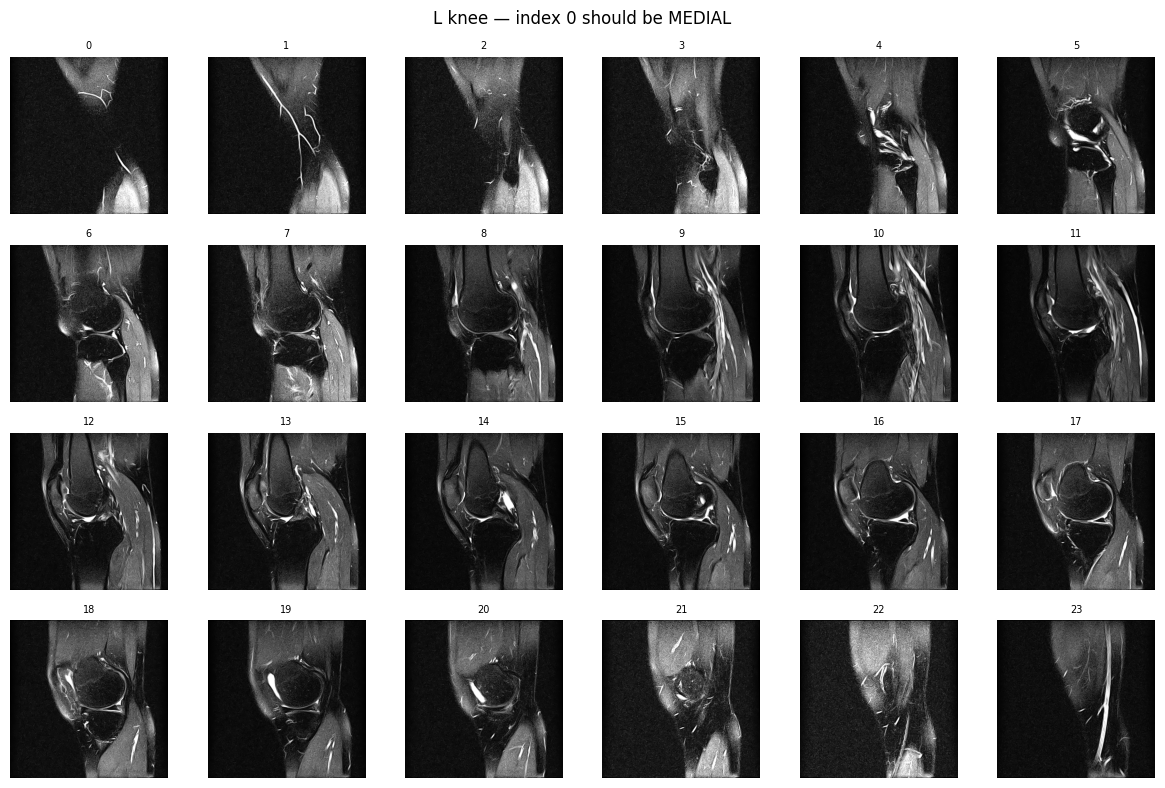

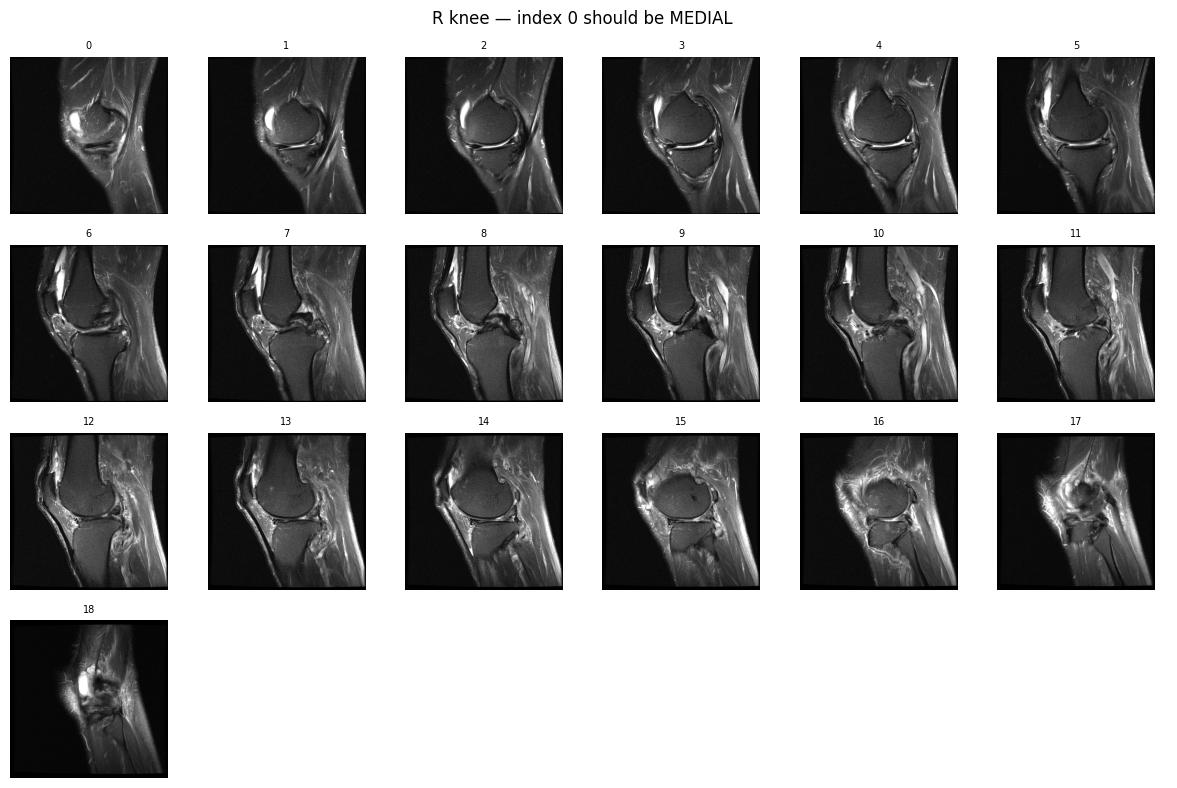

In [14]:
import matplotlib.pyplot as plt
import pydicom

def show_series(rows, title):
    rows = rows.sort_values("slice_index")
    n, cols = len(rows), 6
    fig, axes = plt.subplots(int(np.ceil(n / cols)), cols,
                             figsize=(cols * 2, np.ceil(n / cols) * 2))
    for ax, (_, r) in zip(axes.flat, rows.iterrows()):
        img = pydicom.dcmread(r.path).pixel_array
        lo, hi = np.percentile(img, [0.5, 99.5])
        ax.imshow(img, cmap="gray", vmin=lo, vmax=hi)
        ax.set_title(int(r.slice_index), fontsize=7)
    for ax in axes.flat:
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

sag = df[df.plane == "sagittal"]
for s in ("L", "R"):
    uid = sag[sag.side == s].series_uid.iloc[0]
    show_series(sag[sag.series_uid == uid], f"{s} knee — index 0 should be MEDIAL")

In [15]:
o = sag.sort_values("slice_index")
chk = pd.DataFrame({"side": o.groupby("series_uid").side.first(),
                    "x_first": o.groupby("series_uid").ipp_x.first(),
                    "x_last":  o.groupby("series_uid").ipp_x.last()})
print(pd.crosstab(chk.side, chk.x_first < chk.x_last))

col_0  False  True 
side               
L          0   2071
R       2335      0


# Phase A · Step 4 — Decode pixels

Turns one series' DICOM files into a volume of real-valued numbers. First step
that touches pixels.

**In:** the `cache_index` rows for one series.
**Out:** a `float32` array of shape `(n_slices, H, W)`, in real units, right-side-up.

### 1. Read each slice, in order
Open the DICOM and pull out the image as a grid of numbers. Slices are taken in
`slice_index` order, so the volume is already anatomically ordered.

### 2. Apply rescale slope and intercept
DICOM stores whole numbers plus a recipe for converting them back:

    real value = stored value × RescaleSlope + RescaleIntercept

For 85% of this dataset the values are 1.0 and 0.0, so nothing changes. The
reason to do it anyway: a few Philips series set different values per slice, and
step 5 normalises the whole series with one clip window — so it assumes the
slices already share a scale.

Missing tags default to slope 1, intercept 0.

### 3. Fix inverted images
`PhotometricInterpretation = MONOCHROME1` means higher number = *darker*, the
opposite of normal. Uncorrected, those series look like photographic negatives
and the model reads them as different tissue entirely.

Inverting uses the **whole series'** maximum, not each slice's — a per-slice max
would scale each slice differently, which is exactly the inconsistency step 5
exists to remove.

This dataset is 100% MONOCHROME2, so the branch never fires. It stays as a guard.

### Note on scope
This is a function, not a pass over the dataset. Raw float volumes at native
resolution are far too large to store — 308k slices at 512² float32 is hundreds
of GB. Steps 4–7 run as one loop per series, and only the final uint8 result
lands on disk.

In [16]:
def load_series_volume(rows):
    """Decode one series into a float32 volume in real units, in slice order."""
    rows = rows.sort_values("slice_index")

    slices = []
    for r in rows.itertuples():
        arr = pydicom.dcmread(r.path).pixel_array.astype(np.float32)
        slope = 1.0 if pd.isna(r.rescale_slope) else float(r.rescale_slope)
        intercept = 0.0 if pd.isna(r.rescale_intercept) else float(r.rescale_intercept)
        slices.append(arr * slope + intercept)

    volume = np.stack(slices)

    # MONOCHROME1 is inverted. Use the series max so slices stay on one scale.
    if rows.photometric_interpretation.iat[0] == "MONOCHROME1":
        volume = volume.max() - volume

    return volume


# quick check on one series
uid = df.series_uid.iloc[0]
vol = load_series_volume(df[df.series_uid == uid])
print(vol.shape, vol.dtype, f"range {vol.min():.0f} to {vol.max():.0f}")

(24, 256, 256) float32 range 0 to 948


# Phase A · Step 5 — Normalise intensity

Puts every series on the same brightness scale. Runs on the volume from step 4.

**In:** `float32` volume, arbitrary units.
**Out:** same shape, values in `[0, 1]`.

### Why
MRI numbers don't measure anything absolute. Unlike CT — where water is always 0
Hounsfield on every scanner ever built — MRI values depend on vendor, magnet
strength, coil and receiver gain. The same cartilage can read 300 on one machine
and 3000 on another.

So raw brightness is a property of the *machine*, not the knee. Left alone, the
model can learn "bright images → this scanner → this clinic → more ACL tears",
which improves training loss and collapses on the test set.

### 1. Find the clip window
Take the 0.5th and 99.5th percentiles of the **whole volume** — one window for
all slices, not one per slice. Per-slice windows would scale neighbouring slices
differently, and the 2.5D stack reads differences between neighbours as signal.

### 2. Clip
Anything below `lo` becomes `lo`, anything above `hi` becomes `hi`.

Percentiles rather than min/max because a metal screw or a noise pixel can hit
3000 while all the real tissue sits below 1450. Scaling by the true max would
squeeze the anatomy into the bottom third of the range and waste the rest —
which matters at step 7, where we quantise to 256 grey levels.

### 3. Rescale to [0, 1]

    (value − lo) / (hi − lo)

Subtracting `lo` puts the bottom at 0; dividing by the width puts the top at 1.
The `max(…, 1e-6)` guard stops a blank series dividing by zero — a single NaN
would spread through the network and every weight would become NaN.

### What survives
Absolute scale is thrown away; relative brightness is kept. That's the right
trade: on a fluid-sensitive sequence effusion is brighter than cartilage is
brighter than cortical bone, on every scanner. The pattern is the knee. The
scale was the machine.

In [17]:
def normalise_intensity(volume):
    """Clip to the series' 0.5-99.5 percentile window, rescale to [0, 1]."""
    lo, hi = np.percentile(volume, [0.5, 99.5])
    volume = np.clip(volume, lo, hi)
    return (volume - lo) / max(hi - lo, 1e-6)


norm = normalise_intensity(vol)
print(f"before  {vol.min():.0f} to {vol.max():.0f}")
print(f"after   {norm.min():.3f} to {norm.max():.3f}   mean {norm.mean():.3f}")

before  0 to 948
after   0.000 to 1.000   mean 0.185


# Phase A · Step 6 — Canonicalise laterality

Makes medial appear on the same side of every image, so the model doesn't have
to learn two mirrored conventions.

**In:** normalised volume from step 5, plus that series' `cache_index` rows.
**Out:** same shape, possibly mirrored left-right.

### Why it matters
Six of the twelve labels are side-specific — MCL, medial and lateral meniscus,
medial and lateral OA, and PF OA's context. On a coronal image, medial is on the
left of the frame for one knee and the right for the other. Left uncorrected,
half the dataset teaches the opposite of the other half.

### Sagittal is excluded
A sagittal image's two in-plane axes are front↔back and head↔toe. Medial↔lateral
is the *through-plane* axis — the slice ordering, already fixed in step 3.
Flipping a sagittal image horizontally would reverse anterior and posterior,
which is wrong.

| plane | horizontal image axis | flip? |
| --- | --- | --- |
| sagittal | anterior ↔ posterior | no — handled by step 3 |
| coronal | medial ↔ lateral | yes |
| axial | medial ↔ lateral | yes |

### The rule
Patient-x increases toward the patient's left, with 0 at the midline. So:

- a **left** knee sits at positive x, and its medial side is at *smaller* x
- a **right** knee sits at negative x, and its medial side is at *larger* x

`iop_rx` says which way x runs across the image: positive means moving right in
the frame moves toward the patient's left.

Target is medial on the left of the frame. That needs x increasing rightward for
a left knee, and decreasing rightward for a right knee. Flip when it doesn't
match.

In practice `iop_rx` is +1 on nearly every scanner, so this reduces to "flip
right knees" — but reading it from the geometry costs nothing and survives the
exceptions.

### Note
The `side` column comes from step 3 — the DICOM field where present, otherwise
`sign(mean ipp_x)` at 97.8%. About 1% of studies will be mirrored wrongly. That
is noise we accept; dropping them would cost half the dataset.

In [18]:
def canonicalise_laterality(volume, rows):
    """Flip coronal/axial left-right so medial is always on the left of the frame."""
    if rows.plane.iat[0] == "sagittal":
        return volume

    want = 1.0 if rows.side.iat[0] == "L" else -1.0
    if np.sign(rows.iop_rx.iat[0]) != want:
        volume = np.ascontiguousarray(volume[:, :, ::-1])
    return volume


rows = df[df.series_uid == uid]
flipped = canonicalise_laterality(norm, rows)
print(f"{rows.plane.iat[0]}  side={rows.side.iat[0]}  iop_rx={rows.iop_rx.iat[0]:.0f}  "
      f"flipped={not np.array_equal(flipped, norm)}")

axial  side=R  iop_rx=1  flipped=True


In [19]:
print(df.groupby(["rows", "cols"]).size().sort_values(ascending=False).head())
print((df.cols != df.rows).sum(), "non-square slices selected")

rows  cols
512   512     77479
640   640     48495
320   320     35444
384   384     31729
256   256     12741
dtype: int64
31158 non-square slices selected


rows  cols  pixel_spacing_row  pixel_spacing_col
300   320   0.512500           0.512500               24
310   320   0.487500           0.487500               24
320   290   0.562500           0.562500               24
      300   0.512500           0.512500             5544
            0.546875           0.546875               24
                                                    ... 
936   832   0.192300           0.192300               48
1000  832   0.180000           0.180000               24
1108  832   0.180500           0.180500               24
1120  1444  0.250000           0.250000               24
1280  640   0.250000           0.250000              118
Length: 149, dtype: int64


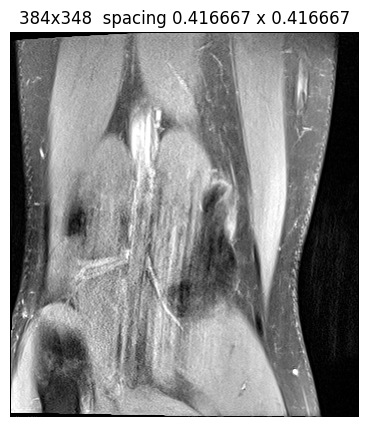

In [20]:
ns = df[df.cols != df.rows]
print(ns.groupby(["rows", "cols", "pixel_spacing_row", "pixel_spacing_col"]).size())

r = ns.iloc[0]
img = pydicom.dcmread(r.path).pixel_array
lo, hi = np.percentile(img, [0.5, 99.5])
plt.figure(figsize=(10, 5))
plt.imshow(img, cmap="gray", vmin=lo, vmax=hi)
plt.title(f"{r.rows}x{r.cols}  spacing {r.pixel_spacing_row} x {r.pixel_spacing_col}")
plt.axis("off"); plt.show()

# Phase A · Step 7 — Crop, resize and store

Writes the cache. Last step of the offline pipeline.

**In:** flipped volume from step 6, values in `[0, 1]`.
**Out:** one `.npy` per series — `uint8`, shape `(n_slices, 224, 224)`.

### 1. Centre-crop to square
31,158 selected slices are non-square, and their pixel spacing is isotropic —
so a 1280×640 frame is genuinely 320mm × 160mm of leg, thigh through calf, not
an oversampled square. Resizing that straight to 224×224 would squash the knee
2:1 and keep a lot of anatomy we don't need.

Cropping the longer axis to match the shorter keeps the joint at its true aspect
ratio. Square frames pass through untouched.

Useful side effect: the short dimension is already ~150–165mm across every
format in this dataset (320×0.5125 = 164mm, 832×0.18 = 150mm, 640×0.25 = 160mm),
so once cropped square the knee occupies a similar fraction of every frame and
no physical-size resampling is needed.

### 2. Resize to 224×224
224 is what RadImageNet was trained at, and every source size here is larger, so
this is always a downscale — no invented detail.

`INTER_AREA` averages the pixels it merges. Bilinear or nearest-neighbour skip
pixels instead, which aliases fine texture into noise — exactly the texture a
meniscal tear lives in.

### 3. Scale to 0–255, cast to uint8
Values are already `[0, 1]` from step 5, so this is a multiply and a round.
uint8 is a quarter the size of float32: ~50 KB per slice, ~15.5 GB total against
Kaggle's 20 GB cap. 256 grey levels is ample once the percentile clip has
removed the outlier range.

### 4. Save one file per series
Named by `series_uid`. One file per *slice* would mean 308k files, where per-file
overhead dominates.

### Check before the full run
The crop assumes the knee sits mid-frame. Display a cropped slice from one of the
1280×640 series — if the joint is off-centre we would need to centre on the
image's brightest mass instead.

(24, 224, 224) uint8 range 0 to 255
1.20 MB this series


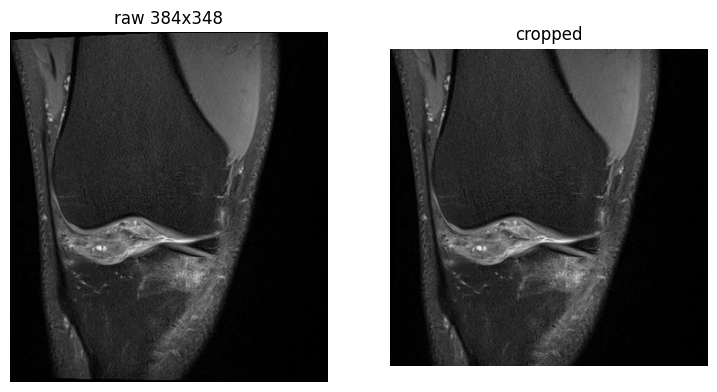

In [21]:
import cv2, os

CACHE_DIR = "/kaggle/working/cache"
os.makedirs(CACHE_DIR, exist_ok=True)

def centre_crop_square(volume):
    """Crop the longer axis so the frame is square. No-op if already square."""
    _, h, w = volume.shape
    s = min(h, w)
    y, x = (h - s) // 2, (w - s) // 2
    return volume[:, y:y + s, x:x + s]


def resize_and_save(volume, series_uid, size=224):
    """Crop square, resize, scale to 0-255 uint8, write one .npy for the series."""
    volume = centre_crop_square(volume)
    out = np.stack([cv2.resize(s, (size, size), interpolation=cv2.INTER_AREA)
                    for s in volume])
    out = (out * 255).round().astype(np.uint8)
    np.save(f"{CACHE_DIR}/{series_uid}.npy", out)
    return out


cached = resize_and_save(flipped, uid)
print(cached.shape, cached.dtype, f"range {cached.min()} to {cached.max()}")
print(f"{cached.nbytes / 1e6:.2f} MB this series")

# the crop assumes the knee is centred -- check on a 2:1 series
tall = df[df.rows != df.cols]
if len(tall):
    r = tall.iloc[0]
    v = load_series_volume(df[df.series_uid == r.series_uid])
    mid = len(v) // 2
    fig, ax = plt.subplots(1, 2, figsize=(9, 5))
    ax[0].imshow(v[mid], cmap="gray"); ax[0].set_title(f"raw {r.rows}x{r.cols}")
    ax[1].imshow(centre_crop_square(v)[mid], cmap="gray"); ax[1].set_title("cropped")
    for a in ax: a.axis("off")
    plt.show()

In [ ]:
from concurrent.futures import ProcessPoolExecutor
from tqdm.auto import tqdm

def build_one(rows):
    """Steps 4-7 for a single series. Returns (uid, error or None)."""
    uid = rows.series_uid.iat[0]
    if os.path.exists(f"{CACHE_DIR}/{uid}.npy"):
        return uid, None                      # already done, resume-safe
    try:
        vol = load_series_volume(rows)        # 4: decode
        vol = normalise_intensity(vol)        # 5: percentile clip to [0,1]
        vol = canonicalise_laterality(vol, rows)  # 6: flip coronal/axial
        resize_and_save(vol, uid)             # 7: crop, resize, write uint8
        return uid, None
    except Exception as e:
        return uid, repr(e)


groups = [g for _, g in df.groupby("series_uid", sort=False)]

errors = []
with ProcessPoolExecutor(max_workers=os.cpu_count()) as pool:
    for uid, err in tqdm(pool.map(build_one, groups, chunksize=8),
                         total=len(groups), desc="caching"):
        if err:
            errors.append((uid, err))

print(f"cached    {len(groups) - len(errors):,} / {len(groups):,} series")
print(f"failures  {len(errors):,}")
for uid, err in errors[:10]:
    print("  ", uid, err)

caching:   0%|          | 0/13218 [00:00<?, ?it/s]

In [ ]:
files = os.listdir(CACHE_DIR)
size = sum(os.path.getsize(f"{CACHE_DIR}/{f}") for f in files)
print(f"{len(files):,} files, {size / 1e9:.1f} GB")

# every series should have as many cached slices as the index says
expected = df.groupby("series_uid").size()
bad = [u for u in expected.index[:500]
       if np.load(f"{CACHE_DIR}/{u}.npy", mmap_mode="r").shape[0] != expected[u]]
print(f"slice-count mismatches in first 500: {len(bad)}")